# Modelo de ronda — sin posición, comparativa de algoritmos

En los notebooks anteriores el modelo incluía la variable `posicion` mediante One Hot Encoding. Aquí exploramos si **entrenar solo con variables numéricas** mejora la predicción, especialmente para perfiles europeos como Aday Mara y Sergio de Larrea, cuya posición no tiene precedente claro en el dataset NCAA.

Además, comparamos cuatro algoritmos: **XGBoost**, **Random Forest**, **SVM (kernel RBF)** y **KNN**.

Importo librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

Cargo el dataset procesado

In [2]:
ncaa = pd.read_csv('../../datos/procesados/ncaa_final.csv')

Compruebo la distribución de la variable target

In [3]:
ncaa['ronda'].value_counts(normalize=True).round(3)

ronda
ND    0.707
R1    0.152
R2    0.141
Name: proportion, dtype: float64

## Preparación de variables — sin posición

Elimino la columna `posicion` antes de crear X. El modelo aprenderá únicamente de las estadísticas numéricas de temporada.

In [4]:
# separo variables y target — elimino posicion directamente
X = ncaa.drop(columns=['ronda', 'rango_pick', 'posicion'])
y = ncaa['ronda']

# transformo el target a numérico
le_ronda = LabelEncoder()
y_enc = le_ronda.fit_transform(y)  # ND=0, R1=1, R2=2

print("Clases:", le_ronda.classes_)
print("Variables en X:", X.shape[1])
print("Distribución:\n", pd.Series(y_enc).value_counts(normalize=True).round(3))

Clases: ['ND' 'R1' 'R2']
Variables en X: 34
Distribución:
 0    0.707
1    0.152
2    0.141
Name: proportion, dtype: float64


Divido en entrenamiento y test con la misma semilla que en el modelo anterior para comparar.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.15,
    random_state=11,
    stratify=y_enc
)

print(X_train.shape, X_test.shape)

(1802, 34) (319, 34)


## Escalado de variables

SVM y KNN son sensibles a la escala de las variables — sin escalar, una columna con valores 0–30 dominaría sobre otra con valores 0–1. Ajusto el scaler solo sobre train y lo aplico a test para evitar fuga de datos.

In [6]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Media tras escalado (primeras 3 cols):", X_train_sc[:, :3].mean(axis=0).round(4))

Media tras escalado (primeras 3 cols): [-0.  0. -0.]


Calculo pesos para compensar el desbalanceo de clases, igual que en el modelo anterior.

In [7]:
pesos = compute_sample_weight(class_weight='balanced', y=y_train)

## XGBoost

Mismo algoritmo que en el notebook anterior, ahora sin posición. Sirve de referencia directa para medir el impacto de eliminar esa variable.

In [8]:
xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=11,
    eval_metric='mlogloss'
)
xgb.fit(X_train, y_train, sample_weight=pesos)

y_pred_xgb = xgb.predict(X_test)
print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, target_names=le_ronda.classes_))

=== XGBoost ===
              precision    recall  f1-score   support

          ND       0.92      0.85      0.88       226
          R1       0.37      0.40      0.38        48
          R2       0.34      0.47      0.40        45

    accuracy                           0.72       319
   macro avg       0.55      0.57      0.55       319
weighted avg       0.76      0.72      0.74       319



## Random Forest

Conjunto de árboles de decisión entrenados en paralelo. A diferencia de XGBoost (que aprende de los errores de forma secuencial), Random Forest promedia árboles independientes — suele ser más robusto ante ruido y funciona bien con pocas muestras por clase.

In [9]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight='balanced',  # equivalente a los pesos manuales
    random_state=11
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=le_ronda.classes_))

=== Random Forest ===
              precision    recall  f1-score   support

          ND       0.92      0.81      0.86       226
          R1       0.48      0.62      0.54        48
          R2       0.36      0.47      0.40        45

    accuracy                           0.73       319
   macro avg       0.59      0.63      0.60       319
weighted avg       0.78      0.73      0.75       319



## SVM con kernel RBF

El SVM busca el hiperplano que mejor separa las clases con el mayor margen posible. El kernel RBF (Radial Basis Function) permite separar clases que no son linealmente separables proyectando los datos a un espacio de mayor dimensión. Es el modelo que estamos estudiando en clase y uno de los más potentes para datasets de tamaño medio.

In [10]:
svm = SVC(
    kernel='rbf',
    C=1.0,            # penalización por errores — mayor C = menos margen, más ajuste
    gamma='scale',    # ajusta automáticamente según el número de variables
    class_weight='balanced',
    probability=True, # necesario para usar predict_proba y calcular AUC-ROC
    random_state=11
)
svm.fit(X_train_sc, y_train)  # SVM usa los datos escalados

y_pred_svm = svm.predict(X_test_sc)
print("=== SVM (kernel RBF) ===")
print(classification_report(y_test, y_pred_svm, target_names=le_ronda.classes_))

=== SVM (kernel RBF) ===
              precision    recall  f1-score   support

          ND       0.95      0.73      0.82       226
          R1       0.40      0.54      0.46        48
          R2       0.33      0.58      0.42        45

    accuracy                           0.68       319
   macro avg       0.56      0.62      0.57       319
weighted avg       0.78      0.68      0.71       319



## KNN (K-Nearest Neighbors)

KNN clasifica cada jugador buscando los K jugadores más similares en el dataset de entrenamiento y asignándole la clase más frecuente entre ellos. No aprende un modelo en el sentido tradicional — simplemente memoriza los datos y compara. Con k=7 buscamos los 7 jugadores históricos más parecidos por sus estadísticas.

In [11]:
knn = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',  # los vecinos más cercanos pesan más que los lejanos
    metric='euclidean'
)
knn.fit(X_train_sc, y_train)  # KNN también usa los datos escalados

y_pred_knn = knn.predict(X_test_sc)
print("=== KNN (k=7) ===")
print(classification_report(y_test, y_pred_knn, target_names=le_ronda.classes_))

=== KNN (k=7) ===
              precision    recall  f1-score   support

          ND       0.80      0.94      0.87       226
          R1       0.37      0.27      0.31        48
          R2       0.39      0.16      0.22        45

    accuracy                           0.73       319
   macro avg       0.52      0.46      0.47       319
weighted avg       0.68      0.73      0.69       319



## Comparativa visual de los cuatro modelos

Represento el F1-score macro de cada modelo para ver cuál generaliza mejor. El F1 macro trata todas las clases por igual — es la métrica más honesta cuando hay desbalanceo.

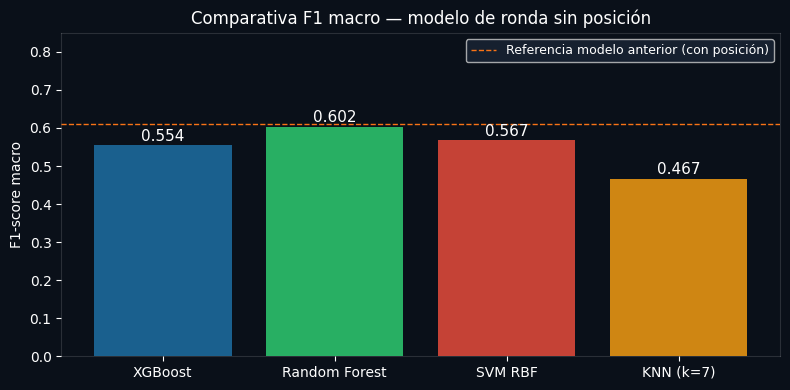

F1 macro por modelo:
  XGBoost          0.5541
  Random Forest    0.6016
  SVM RBF          0.5671
  KNN (k=7)        0.4671


In [12]:
from sklearn.metrics import f1_score

modelos_nombres = ['XGBoost', 'Random Forest', 'SVM RBF', 'KNN (k=7)']
predicciones    = [y_pred_xgb, y_pred_rf, y_pred_svm, y_pred_knn]
colores_mod     = ['#1d6fa4', '#2ecc71', '#e74c3c', '#f39c12']

f1_macros = [f1_score(y_test, p, average='macro') for p in predicciones]

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#0a1019')
ax.set_facecolor('#0a1019')

barras = ax.bar(modelos_nombres, f1_macros, color=colores_mod, alpha=0.85)
for b, v in zip(barras, f1_macros):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
            f'{v:.3f}', ha='center', va='bottom', color='white', fontsize=11)

ax.set_ylim(0, 0.85)
ax.set_ylabel('F1-score macro', color='white')
ax.set_title('Comparativa F1 macro — modelo de ronda sin posición', color='white', fontsize=12)
ax.tick_params(colors='white')
ax.axhline(y=0.61, color='#f97316', linestyle='--', linewidth=1, label='Referencia modelo anterior (con posición)')
ax.legend(facecolor='#1a2535', labelcolor='white', fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#ffffff22')

plt.tight_layout()
plt.show()

print("F1 macro por modelo:")
for nombre, f1 in zip(modelos_nombres, f1_macros):
    print(f"  {nombre:<15}  {f1:.4f}")

## AUC-ROC comparativa

El AUC-ROC mide la capacidad de separación de cada modelo clase por clase. Comparo los cuatro modelos en la misma gráfica para ver cuál separa mejor R1 y R2.

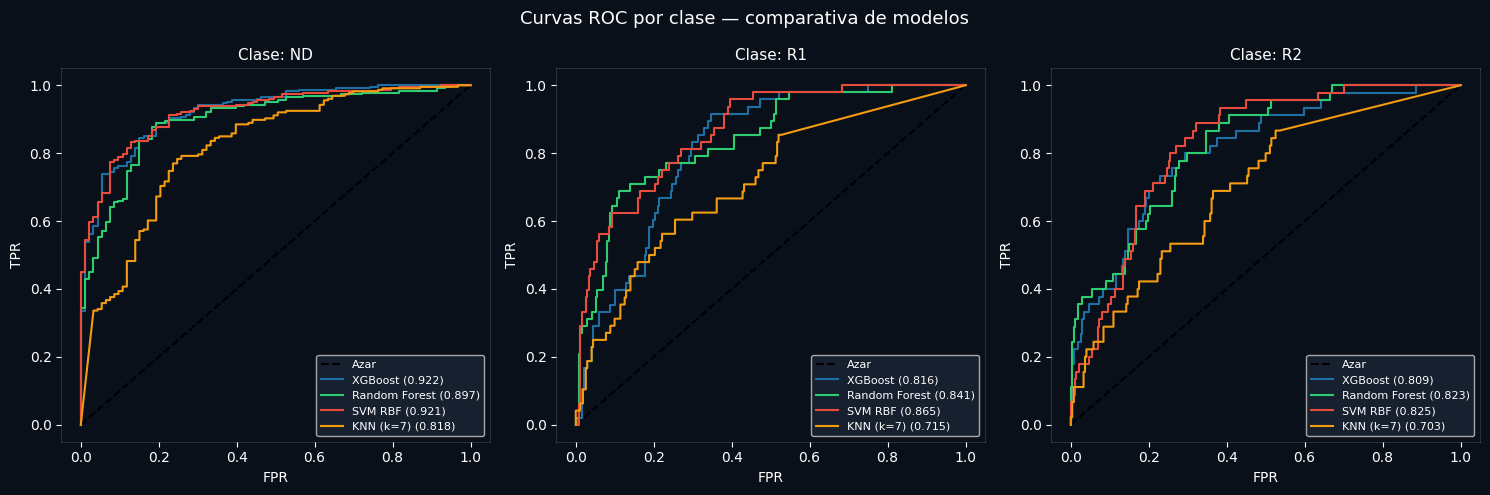

In [13]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

modelos_eval = {
    'XGBoost':        (xgb,  X_test),
    'Random Forest':  (rf,   X_test),
    'SVM RBF':        (svm,  X_test_sc),
    'KNN (k=7)':      (knn,  X_test_sc),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#0a1019')
colores_mod = ['#1d6fa4', '#2ecc71', '#e74c3c', '#f39c12']

for i, (nombre_clase, idx_clase) in enumerate(zip(le_ronda.classes_, [0, 1, 2])):
    ax = axes[i]
    ax.set_facecolor('#0a1019')
    ax.set_title(f'Clase: {nombre_clase}', color='white', fontsize=11)
    ax.set_xlabel('FPR', color='white')
    ax.set_ylabel('TPR', color='white')
    ax.tick_params(colors='white')
    ax.plot([0,1],[0,1],'k--', label='Azar')

    for (nombre_mod, (mod, X_eval)), color in zip(modelos_eval.items(), colores_mod):
        probs = mod.predict_proba(X_eval)
        auc = roc_auc_score(y_test_bin[:, idx_clase], probs[:, idx_clase])
        fpr, tpr, _ = roc_curve(y_test_bin[:, idx_clase], probs[:, idx_clase])
        ax.plot(fpr, tpr, color=color, label=f'{nombre_mod} ({auc:.3f})')

    ax.legend(facecolor='#1a2535', labelcolor='white', fontsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#ffffff22')

plt.suptitle('Curvas ROC por clase — comparativa de modelos', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## Elección del modelo final

Selecciono el modelo con mejor F1 macro para guardarlo y usarlo en las predicciones finales. Si hay empate técnico entre dos modelos, prefiero XGBoost por ser el más interpretable mediante importancia de variables.

Mejor modelo: Random Forest  (F1 macro = 0.6016)


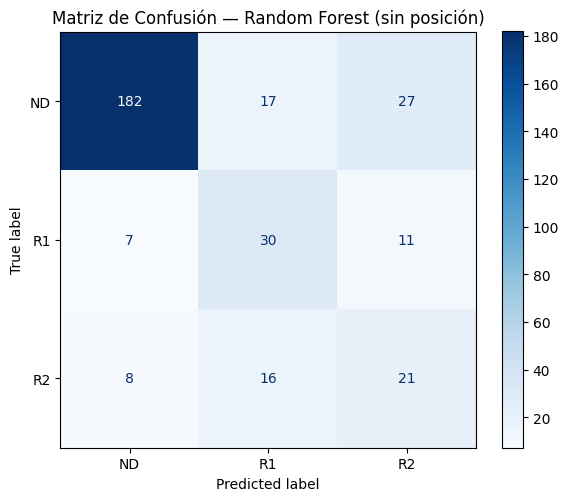

In [14]:
mejor_idx  = int(np.argmax(f1_macros))
mejor_nombre = modelos_nombres[mejor_idx]
mejor_modelo, mejor_X_test = list(modelos_eval.values())[mejor_idx]

print(f"Mejor modelo: {mejor_nombre}  (F1 macro = {f1_macros[mejor_idx]:.4f})")

# matriz de confusión del ganador
y_pred_mejor = mejor_modelo.predict(mejor_X_test)
cm = confusion_matrix(y_test, y_pred_mejor)
disp = ConfusionMatrixDisplay(cm, display_labels=le_ronda.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title(f'Matriz de Confusión — {mejor_nombre} (sin posición)')
plt.tight_layout()
plt.show()

Guardo el mejor modelo y el scaler para poder reutilizarlos en las predicciones.

In [15]:
os.makedirs('../../pkl/modelos', exist_ok=True)
os.makedirs('../../pkl/preprocesado', exist_ok=True)

joblib.dump(mejor_modelo,  '../../pkl/modelos/modelo_ronda_sin_posicion.pkl')
joblib.dump(le_ronda,      '../../pkl/preprocesado/le_ronda_sin_posicion.pkl')
joblib.dump(scaler,        '../../pkl/preprocesado/scaler_ronda.pkl')

print("Modelo guardado:", mejor_nombre)

Modelo guardado: Random Forest


## Predicción para los tres españoles — ronda

Introduzco las estadísticas de temporada 2025-26 de los tres candidatos. Como el modelo ya no tiene la variable posición, no hay columnas dummy que rellenar. Uso `predict_proba` para ver la distribución completa de probabilidades.

> ⚠️ **Nota metodológica:** el dataset de entrenamiento cubre la NCAA americana 2009–2021. Los perfiles europeos (Mara, De Larrea) no tienen precedente en esos datos. La probabilidad combinada R1+R2 es la señal más relevante para ellos.

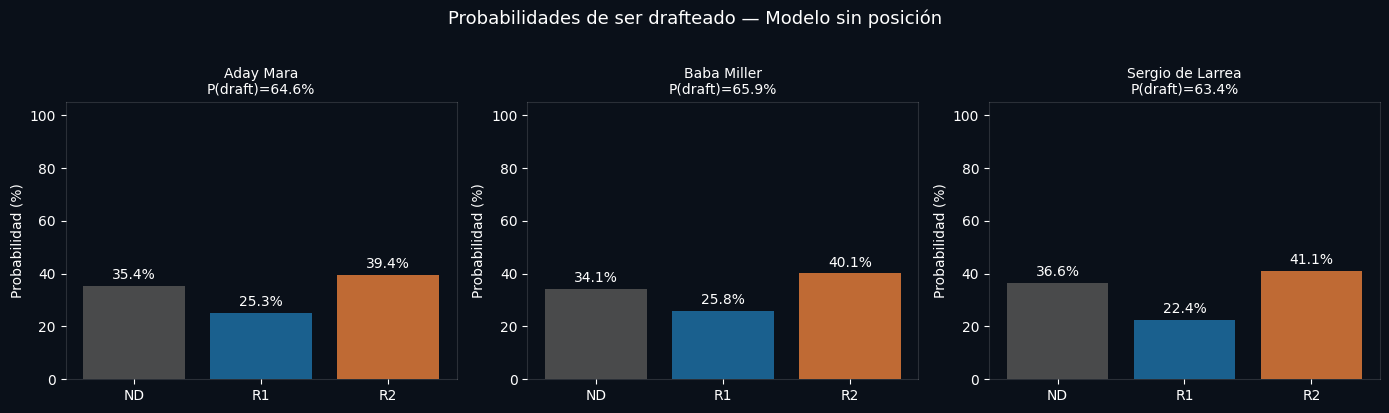


--- Tabla resumen ---
  Aday Mara              ND=35.4%  R1=25.3%  R2=39.4%  → P(draft)=64.6%
  Baba Miller            ND=34.1%  R1=25.8%  R2=40.1%  → P(draft)=65.9%
  Sergio de Larrea       ND=36.6%  R1=22.4%  R2=41.1%  → P(draft)=63.4%


In [16]:
espanoles = [
    {"nombre": "Aday Mara",        "pts": 12.1, "treb": 6.8, "ast": 0.9, "stl": 0.4, "blk": 2.6},
    {"nombre": "Baba Miller",      "pts": 13.0, "treb": 10.3, "ast": 1.2, "stl": 0.8, "blk": 0.9},
    {"nombre": "Sergio de Larrea", "pts": 9.5,  "treb": 3.1,  "ast": 4.2, "stl": 1.1, "blk": 0.2},
]

clases = le_ronda.classes_
colores_clases = {"ND": "#555555", "R1": "#1d6fa4", "R2": "#e07b39"}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.patch.set_facecolor("#0a1019")
fig.suptitle("Probabilidades de ser drafteado — Modelo sin posición", color="white", fontsize=13, y=1.02)

for ax, jugador in zip(axes, espanoles):
    X_esp = pd.DataFrame(0, index=[0], columns=X_train.columns)
    for col in ["pts", "treb", "ast", "stl", "blk"]:
        if col in X_esp.columns:
            X_esp[col] = jugador[col]

    # uso el scaler si el mejor modelo lo necesita (SVM o KNN)
    X_input = scaler.transform(X_esp) if mejor_nombre in ["SVM RBF", "KNN (k=7)"] else X_esp

    probs = mejor_modelo.predict_proba(X_input)[0]
    prob_draft = sum(p for c, p in zip(clases, probs) if c != "ND") * 100
    colores = [colores_clases.get(c, "#888") for c in clases]

    ax.set_facecolor("#0a1019")
    barras = ax.bar(clases, probs * 100, color=colores, alpha=0.85)
    for barra, prob in zip(barras, probs):
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 1.5,
                f"{prob*100:.1f}%", ha="center", va="bottom", color="white", fontsize=10)
    ax.set_ylim(0, 105)
    ax.set_title(f"{jugador['nombre']}\nP(draft)={prob_draft:.1f}%", color="white", fontsize=10)
    ax.set_ylabel("Probabilidad (%)", color="white")
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#ffffff22")

plt.tight_layout()
plt.show()

print("\n--- Tabla resumen ---")
for jugador in espanoles:
    X_esp = pd.DataFrame(0, index=[0], columns=X_train.columns)
    for col in ["pts", "treb", "ast", "stl", "blk"]:
        if col in X_esp.columns:
            X_esp[col] = jugador[col]
    X_input = scaler.transform(X_esp) if mejor_nombre in ["SVM RBF", "KNN (k=7)"] else X_esp
    probs = mejor_modelo.predict_proba(X_input)[0]
    prob_draft = sum(p for c, p in zip(clases, probs) if c != "ND") * 100
    print(f"  {jugador['nombre']:<22} ND={probs[0]*100:.1f}%  R1={probs[1]*100:.1f}%  R2={probs[2]*100:.1f}%  → P(draft)={prob_draft:.1f}%")

Al eliminar la posición, el modelo ve a los tres con probabilidades similares de ser drafteados (~65%). La diferencia entre un pick 9 y un pick 45 que los scouts sí perciben claramente no aparece en los números — eso nos dice que el valor de Aday Mara está en dimensiones que las estadísticas no miden: atletismo, techo físico, impacto defensivo. Ahí está el límite del modelo y el valor del ojo humano